# Notebook 02b — SVI/SSVI : la boîte à outils **complète** de Gatheral-Jacquier

NB02 calibrait SVI/SSVI de façon robuste (méthode de Zeliade) mais n'implémentait qu'une partie du papier. Ce notebook complète le tableau avec **toutes** les techniques présentées, chacune validée — quand c'est possible — contre les **chiffres exacts** du papier.

**Contenu :**
1. Les **trois paramétrisations** (raw 3.1, naturelle 3.2, SVI-JW 3.3) et leurs **conversions exactes** (Lemmas 3.1, 3.2). Validées par aller-retour + sur l'exemple de Vogt.
2. Arbitrage statique : $g(k)\ge 0$ **et** la 2ᵉ condition butterfly ($d_+\to-\infty$ ⟺ pente d'aile $<2$, Lemma 2.2) ; **crossedness** calendaire (Déf. 5.1).
3. La **recette de calibration du papier** (§5.2) : initialisation *square-root SVI*, puis slice-by-slice avec pénalité de crossedness (élimine l'arbitrage calendaire).
4. L'**algorithme d'élimination du butterfly** (§5.1) via SVI-JW — la contribution phare. On **reproduit l'Exemple 5.1** (smile de Vogt).
5. Les **variantes SSVI** : power-law (Ex. 4.2), Heston-like (Ex. 4.1), et la power-law **modifiée** (4.5) *garantie* sans arbitrage statique. Conditions des Théorèmes 4.1 (calendar) & 4.2 (butterfly).
6. **Interpolation** (Lemma 5.1) et **extrapolation** (§5.3, Théorème 4.3) sans arbitrage.

> Note : en dérivant l'inverse SVI-JW→raw (Lemma 3.2), on corrige un terme manquant dans l'énoncé OCR du papier ; la version implémentée ici est validée numériquement sur Vogt (elle retrouve exactement les paramètres raw).


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize, brentq
from scipy.stats import norm
np.set_printoptions(precision=6, suppress=True)
plt.rcParams["figure.figsize"] = (7, 4.2); plt.rcParams["axes.grid"] = True; plt.rcParams["grid.alpha"] = .3

# --- raw SVI (rappel NB00) ---
def svi_raw(k, a, b, rho, m, sigma):
    k = np.asarray(k, float); return a + b * (rho * (k - m) + np.sqrt((k - m) ** 2 + sigma ** 2))
def svi_prime(k, a, b, rho, m, sigma):
    k = np.asarray(k, float); return b * (rho + (k - m) / np.sqrt((k - m) ** 2 + sigma ** 2))
def svi_double(k, a, b, rho, m, sigma):
    k = np.asarray(k, float); return b * sigma ** 2 / ((k - m) ** 2 + sigma ** 2) ** 1.5
def durrleman_g(k, w, wp, wpp):
    return (1 - k * wp / (2 * w)) ** 2 - (wp ** 2 / 4) * (1 / w + .25) + wpp / 2


## 1. Les trois paramétrisations et leurs conversions

**Raw** (3.1) : $w=a+b(\rho(k-m)+\sqrt{(k-m)^2+\sigma^2})$.
**Naturelle** (3.2) : $w=\Delta+\frac{\omega}{2}(1+\zeta\rho(k-\mu)+\sqrt{(\zeta(k-\mu)+\rho)^2+1-\rho^2})$.
**SVI-JW** (3.5) : paramètres $(v_t,\psi_t,p_t,c_t,\tilde v_t)$ = variance ATM, skew ATM, pente put, pente call, variance minimale — les grandeurs *parlantes* pour un trader, et le véhicule de l'élimination du butterfly.

Conversions raw↔naturelle (Lemma 3.1) et raw↔SVI-JW (Lemma 3.2, avec le terme corrigé).

In [2]:
# ---------- raw <-> natural (Lemma 3.1) ----------
def raw_to_natural(a, b, rho, m, sigma):
    r = np.sqrt(1 - rho ** 2)
    zeta = r / sigma
    omega = 2 * b * sigma / r
    mu = m + rho * sigma / r
    Delta = a - 0.5 * omega * (1 - rho ** 2)
    return dict(Delta=Delta, mu=mu, rho=rho, omega=omega, zeta=zeta)

def natural_to_raw(Delta, mu, rho, omega, zeta):
    r = np.sqrt(1 - rho ** 2)
    b = 0.5 * omega * zeta
    m = mu - rho / zeta
    sigma = r / zeta
    a = Delta + 0.5 * omega * (1 - rho ** 2)
    return dict(a=a, b=b, rho=rho, m=m, sigma=sigma)

# ---------- raw <-> SVI-JW (Lemma 3.2 ; formule inverse corrigée) ----------
def raw_to_jw(a, b, rho, m, sigma, t):
    w0 = a + b * (-rho * m + np.sqrt(m ** 2 + sigma ** 2))   # w(0) = total variance ATM
    wt = w0
    sq = np.sqrt(wt)
    vt = w0 / t
    psit = b / (2 * sq) * (rho - m / np.sqrt(m ** 2 + sigma ** 2))
    pt = b * (1 - rho) / sq
    ct = b * (1 + rho) / sq
    vtil = (a + b * sigma * np.sqrt(1 - rho ** 2)) / t
    return dict(vt=vt, psit=psit, pt=pt, ct=ct, vtil=vtil)

def jw_to_raw(vt, psit, pt, ct, vtil, t):
    wt = vt * t
    sq = np.sqrt(wt)
    b = sq * (ct + pt) / 2
    rho = (ct - pt) / (ct + pt)
    beta = rho - 2 * psit * sq / b
    beta = np.clip(beta, -0.9999999, 0.9999999)
    alpha = np.sign(beta) * np.sqrt(1 / beta ** 2 - 1)
    r = np.sqrt(1 - rho ** 2)
    # (vt - vtil) t = b*m*(1/beta - rho - alpha*sqrt(1-rho^2))   [sqrt(m^2+sig^2)=m/beta, gère m<0]
    denom = b * (1.0 / beta - rho - alpha * r)
    m = (vt - vtil) * t / denom if abs(denom) > 1e-14 else 0.0
    sigma = alpha * m
    a = vtil * t - b * sigma * r
    return dict(a=a, b=b, rho=rho, m=m, sigma=sigma)


In [3]:
# --- validation : aller-retour sur des paramètres aléatoires ---
rng = np.random.default_rng(0)
maxerr = 0.0
for _ in range(2000):
    p = dict(a=rng.uniform(0, .05), b=rng.uniform(.05, .3), rho=rng.uniform(-.9, .9),
             m=rng.uniform(-.3, .3), sigma=rng.uniform(.05, .5))
    back_n = natural_to_raw(**raw_to_natural(**p))
    t = rng.uniform(.1, 2)
    back_j = jw_to_raw(**raw_to_jw(t=t, **p), t=t)
    for key in p:
        maxerr = max(maxerr, abs(p[key] - back_n[key]), abs(p[key] - back_j[key]))
print(f"erreur max aller-retour (raw<->naturelle<->SVI-JW) : {maxerr:.2e}")

# --- validation sur l'exemple de Vogt : reproduire les SVI-JW du papier ---
vogt = dict(a=-0.0410, b=0.1331, rho=0.3060, m=0.3586, sigma=0.4153)
jw = raw_to_jw(**vogt, t=1.0)
print("\nSVI-JW de Vogt (papier: 0.01742625, -0.1752111, 0.6997381, 1.316798, 0.0116249) :")
print("  calculé      :", {k: round(v, 7) for k, v in jw.items()})
back = jw_to_raw(**jw, t=1.0)
print("  raw reconstruit:", {k: round(v, 4) for k, v in back.items()}, "  (vrai:", vogt, ")")


erreur max aller-retour (raw<->naturelle<->SVI-JW) : 2.72e-10

SVI-JW de Vogt (papier: 0.01742625, -0.1752111, 0.6997381, 1.316798, 0.0116249) :
  calculé      : {'vt': np.float64(0.0174263), 'psit': np.float64(-0.1752111), 'pt': np.float64(0.6997381), 'ct': np.float64(1.3167982), 'vtil': np.float64(0.0116249)}
  raw reconstruit: {'a': np.float64(-0.041), 'b': np.float64(0.1331), 'rho': np.float64(0.306), 'm': np.float64(0.3586), 'sigma': np.float64(0.4153)}   (vrai: {'a': -0.041, 'b': 0.1331, 'rho': 0.306, 'm': 0.3586, 'sigma': 0.4153} )


## 2. Arbitrage statique : les deux conditions butterfly + crossedness calendaire

**Butterfly** (Lemma 2.2) : (i) $g(k)\ge 0$ partout, **et** (ii) $\lim_{k\to\infty}d_+(k)=-\infty$. Pour SVI raw, (ii) équivaut aux **pentes d'ailes $<2$** : $b(1+\rho)<2$ et $b(1-\rho)<2$ (borne de Lee).

**Calendar** (Déf. 5.1) : deux tranches ne doivent pas se croiser. La *crossedness* mesure de combien la tranche courte dépasse la longue.

In [4]:
def svi_butterfly_ok(params, k_lo=-2.0, k_hi=2.0, n=800):
    """(min g, pentes<2 ?) -> tranche sans butterfly ssi min g>=0 ET wings_ok."""
    k = np.linspace(k_lo, k_hi, n)
    g = durrleman_g(k, svi_raw(k, **params), svi_prime(k, **params), svi_double(k, **params))
    b, rho = params["b"], params["rho"]
    wings_ok = (b * (1 + rho) < 2) and (b * (1 - rho) < 2)
    return float(g.min()), bool(wings_ok)

def crossedness(p_short, p_long, k_lo=-1.5, k_hi=1.5, n=400):
    """Déf 5.1 : max(0, w_court - w_long). >0 => arbitrage calendaire."""
    k = np.linspace(k_lo, k_hi, n)
    diff = svi_raw(k, **p_short) - svi_raw(k, **p_long)
    return float(max(0.0, diff.max()))

# démonstration sur Vogt : g<0 (butterfly), et wings ?
ming, wok = svi_butterfly_ok(vogt)
print(f"Vogt : min g = {ming:.4f}  ({'OK' if ming>=0 else 'ARBITRAGE butterfly'}),  pentes<2 : {wok}")


Vogt : min g = -0.0329  (ARBITRAGE butterfly),  pentes<2 : True


## 3. Recette de calibration du papier (§5.2)

Contrairement à NB02 (Zeliade), on suit ici la recette *originale* : (a) une **initialisation square-root SVI** — le smile scale en $1/\sqrt{w_t}$, c'est-à-dire SSVI avec $\gamma=1/2$ (pentes $\psi_t,p_t,c_t$ constantes) ; (b) un raffinement **slice-by-slice** minimisant l'erreur de fit **plus une lourde pénalité de crossedness** contre la tranche précédente, ce qui élimine l'arbitrage calendaire.

In [5]:
def ssvi_w(k, theta, rho, eta, gamma):
    k = np.asarray(k, float); phi = eta * theta ** (-gamma)
    return 0.5 * theta * (1 + rho * phi * k + np.sqrt((phi * k + rho) ** 2 + (1 - rho ** 2)))

def sqrt_svi_init(taus, thetas, k_lists, w_lists):
    """Initialisation square-root SVI = SSVI power-law avec gamma=1/2."""
    TH = np.asarray(thetas, float)
    def sse(p):
        rho, eta = p; tot = 0.0
        for th, kk, wm in zip(TH, k_lists, w_lists):
            tot += np.sum((ssvi_w(kk, th, rho, eta, 0.5) - wm) ** 2)
        return tot
    best = None
    for init in [(-0.5, 1.0), (-0.7, 0.5), (-0.3, 1.5)]:
        r = minimize(sse, init, method="Nelder-Mead")
        if best is None or r.fun < best.fun: best = r
    rho, eta = best.x
    # tranche initiale = SSVI(gamma=0.5) convertie en raw via natural
    init_raw = []
    for th in TH:
        phi = eta * th ** (-0.5)
        nat = dict(Delta=0.0, mu=0.0, rho=rho, omega=th, zeta=phi)
        init_raw.append(natural_to_raw(**nat))
    return init_raw, dict(rho=rho, eta=eta, gamma=0.5)

def calibrate_surface(taus, k_lists, w_lists, lam=1e3):
    """Recette §5.2 : init sqrt-SVI puis slice-by-slice avec pénalité de crossedness."""
    order = np.argsort(taus)
    taus = [taus[i] for i in order]; k_lists = [k_lists[i] for i in order]; w_lists = [w_lists[i] for i in order]
    thetas0 = [np.interp(0.0, k_lists[i], w_lists[i]) if len(k_lists[i]) else 0.04 for i in range(len(taus))]
    init_raw, _ = sqrt_svi_init(taus, thetas0, k_lists, w_lists)
    fitted = []
    for i, (kk, wm) in enumerate(zip(k_lists, w_lists)):
        x0 = init_raw[i]
        p0 = np.array([x0["a"], x0["b"], x0["rho"], x0["m"], x0["sigma"]])
        prev = fitted[i - 1] if i > 0 else None
        def obj(x):
            a, b, rho, m, s = x
            if b < 0 or s <= 1e-4 or abs(rho) >= 1: return 1e6
            p = dict(a=a, b=b, rho=rho, m=m, sigma=s)
            fit = np.sum((svi_raw(kk, **p) - wm) ** 2)
            pen = lam * crossedness(prev, p) ** 2 if prev is not None else 0.0
            return fit + pen
        r = minimize(obj, p0, method="Nelder-Mead",
                     options={"maxiter": 2000, "xatol": 1e-8, "fatol": 1e-12})
        a, b, rho, m, s = r.x
        fitted.append(dict(a=a, b=b, rho=rho, m=m, sigma=s))
    return taus, fitted


In [6]:
# --- démonstration : surface synthétique AVEC un croisement injecté ---
TRUE = dict(rho=-0.5, eta=0.8, gamma=0.4)
taus = [0.1, 0.3, 0.6, 1.0]
thetas = [0.04 * t for t in taus]
k_lists, w_lists = [], []
for i, (t, th) in enumerate(zip(taus, thetas)):
    kk = np.sort(rng.uniform(-0.5, 0.35, 14))
    wm = ssvi_w(kk, th, **TRUE) * (1 + 0.01 * rng.standard_normal(len(kk)))
    if i == 1:  # on gonfle artificiellement une tranche courte -> croisement calendaire
        wm = wm * 1.5
    k_lists.append(kk); w_lists.append(wm)

_, fit_naive = calibrate_surface(taus, k_lists, w_lists, lam=0.0)   # sans pénalité
_, fit_cal = calibrate_surface(taus, k_lists, w_lists, lam=1e4)     # avec pénalité crossedness
def total_cross(fitted):
    return sum(crossedness(fitted[i], fitted[i + 1]) for i in range(len(fitted) - 1))
print(f"crossedness totale  sans pénalité : {total_cross(fit_naive):.5f}")
print(f"crossedness totale  avec pénalité : {total_cross(fit_cal):.5f}   (doit être ~0)")


crossedness totale  sans pénalité : 0.15080
crossedness totale  avec pénalité : 0.00000   (doit être ~0)


## 4. Élimination du butterfly via SVI-JW (§5.1) — reproduction de l'Exemple 5.1

Étant donné $(v_t,\psi_t,p_t)$, on **garantit** l'absence de butterfly en choisissant
$$ c'_t = p_t + 2\psi_t, \qquad \tilde v'_t = v_t\,\frac{4\,p_t\,c'_t}{(p_t+c'_t)^2}. $$
On applique ça au smile de Vogt et on doit retrouver les valeurs du papier : $(c'_t,\tilde v'_t)=(0.3493158, 0.0154818)$.

c'_t   = 0.3493158   (papier 0.3493158)
vtil'  = 0.0154818   (papier 0.0154818)

min g(k)  avant = -0.0329  (arbitrage)
min g(k)  après = 0.2704  (OK sans arbitrage)


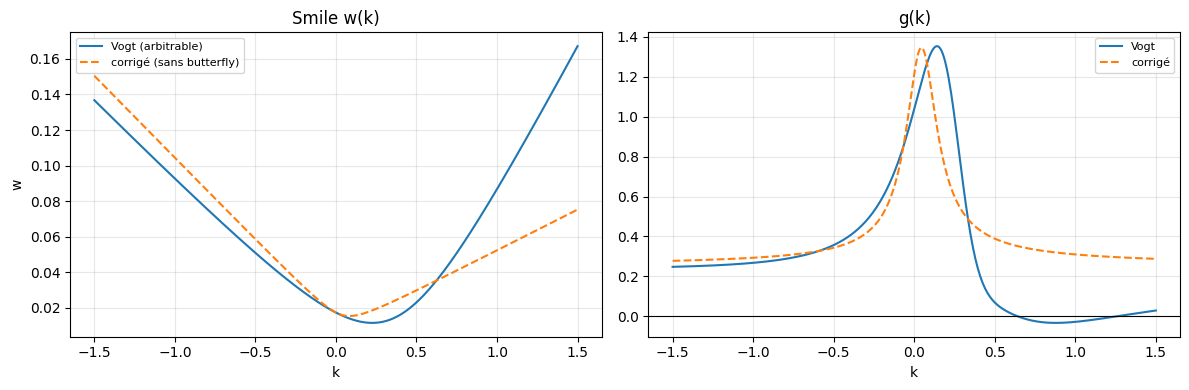

In [7]:
def eliminate_butterfly_jw(jw):
    """Choix garanti sans butterfly (§5.1) : ajuste (ct, vtil) en gardant (vt, psit, pt)."""
    vt, psit, pt = jw["vt"], jw["psit"], jw["pt"]
    ct_new = pt + 2 * psit
    vtil_new = vt * 4 * pt * ct_new / (pt + ct_new) ** 2
    out = dict(jw); out["ct"] = ct_new; out["vtil"] = vtil_new
    return out

jw_vogt = raw_to_jw(**vogt, t=1.0)
jw_fixed = eliminate_butterfly_jw(jw_vogt)
print(f"c'_t   = {jw_fixed['ct']:.7f}   (papier 0.3493158)")
print(f"vtil'  = {jw_fixed['vtil']:.7f}   (papier 0.0154818)")

raw_fixed = jw_to_raw(**jw_fixed, t=1.0)
ming_before, _ = svi_butterfly_ok(vogt)
ming_after, wok_after = svi_butterfly_ok(raw_fixed)
print(f"\nmin g(k)  avant = {ming_before:.4f}  (arbitrage)")
print(f"min g(k)  après = {ming_after:.4f}  ({'OK sans arbitrage' if ming_after>=0 else 'encore arbitrage'})")

kk = np.linspace(-1.5, 1.5, 400)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(kk, svi_raw(kk, **vogt), label="Vogt (arbitrable)")
ax[0].plot(kk, svi_raw(kk, **raw_fixed), "--", label="corrigé (sans butterfly)")
ax[0].set(title="Smile w(k)", xlabel="k", ylabel="w"); ax[0].legend(fontsize=8)
for p, lab, st in [(vogt, "Vogt", "-"), (raw_fixed, "corrigé", "--")]:
    g = durrleman_g(kk, svi_raw(kk, **p), svi_prime(kk, **p), svi_double(kk, **p))
    ax[1].plot(kk, g, st, label=lab)
ax[1].axhline(0, color="k", lw=.8); ax[1].set(title="g(k)", xlabel="k"); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()


## 5. Variantes SSVI : power-law, Heston-like, power-law modifiée (garantie sans arbitrage)

Trois choix de $\varphi$ :
- **power-law** (Ex. 4.2) : $\varphi=\eta\theta^{-\gamma}$, $0<\gamma<1$.
- **Heston-like** (Ex. 4.1) : $\varphi(\theta)=\frac{1}{\lambda\theta}\big(1-\frac{1-e^{-\lambda\theta}}{\lambda\theta}\big)$.
- **power-law modifiée** (4.5) : $\varphi(\theta)=\frac{\eta}{\theta^\gamma(1+\theta)^{1-\gamma}}$, **entièrement sans arbitrage statique** si $\eta(1+|\rho|)\le 2$.

Vérifications : Théorème 4.2 (butterfly : $\theta\varphi(1+|\rho|)<4$ et $\theta\varphi^2(1+|\rho|)\le4$) et Théorème 4.1 (calendar : $\partial_\theta(\theta\varphi)\in[0,\frac{1+\sqrt{1-\rho^2}}{\rho^2}\varphi]$).

In [8]:
def phi_powerlaw(theta, eta, gamma): return eta * theta ** (-gamma)
def phi_heston(theta, lam):
    x = lam * theta
    return (1.0 / x) * (1 - (1 - np.exp(-x)) / x)
def phi_modified(theta, eta, gamma): return eta / (theta ** gamma * (1 + theta) ** (1 - gamma))

def ssvi_w_phi(k, theta, rho, phi_val):
    k = np.asarray(k, float)
    return 0.5 * theta * (1 + rho * phi_val * k + np.sqrt((phi_val * k + rho) ** 2 + (1 - rho ** 2)))

def ssvi_butterfly_ok(thetas, rho, phi_fun, **kw):
    """Théorème 4.2."""
    TH = np.asarray(thetas, float); ph = phi_fun(TH, **kw)
    c1 = np.max(TH * ph * (1 + abs(rho)))
    c2 = np.max(TH * ph ** 2 * (1 + abs(rho)))
    return bool(c1 < 4 and c2 <= 4), float(c1), float(c2)

def ssvi_calendar_ok_num(thetas, rho, phi_fun, k_lo=-1.0, k_hi=1.0, n=200, **kw):
    """Calendar : w(k,theta) non décroissant en theta (numérique)."""
    TH = np.sort(np.asarray(thetas, float)); kk = np.linspace(k_lo, k_hi, n)
    W = np.vstack([ssvi_w_phi(kk, th, rho, phi_fun(th, **kw)) for th in TH])
    return bool(np.all(np.diff(W, axis=0) >= -1e-10))

thetas = np.array([0.01, 0.02, 0.04, 0.08, 0.12])
rho = -0.5
print("Power-law (eta=0.8, gamma=0.4) :",
      ssvi_butterfly_ok(thetas, rho, phi_powerlaw, eta=0.8, gamma=0.4),
      "calendar", ssvi_calendar_ok_num(thetas, rho, phi_powerlaw, eta=0.8, gamma=0.4))
print("Heston-like (lam=1.0)          :",
      ssvi_butterfly_ok(thetas, rho, phi_heston, lam=1.0),
      "calendar", ssvi_calendar_ok_num(thetas, rho, phi_heston, lam=1.0))
# power-law modifiée : garantie si eta(1+|rho|)<=2
eta_mod = 2.0 / (1 + abs(rho)) - 1e-6
print(f"Modifiée (eta={eta_mod:.3f}, garantie car eta(1+|rho|)<=2) :",
      ssvi_butterfly_ok(thetas, rho, phi_modified, eta=eta_mod, gamma=0.5),
      "calendar", ssvi_calendar_ok_num(thetas, rho, phi_modified, eta=eta_mod, gamma=0.5))


Power-law (eta=0.8, gamma=0.4) : (True, 0.33627144776481666, 0.628213814343588) calendar True
Heston-like (lam=1.0)          : (True, 0.08650545896446843, 0.04157330239251851) calendar True
Modifiée (eta=1.333, garantie car eta(1+|rho|)<=2) : (True, 0.654653179717724, 2.6402600660080857) calendar True


## 6. Interpolation (Lemma 5.1) et extrapolation (§5.3) sans arbitrage

**Interpolation** entre deux tranches sans arbitrage $t_1<t<t_2$ : on interpole les **prix** en $\sqrt\theta$,
$$ \frac{C_t}{K_t}=\alpha_t\frac{C_1}{K_1}+(1-\alpha_t)\frac{C_2}{K_2},\quad \alpha_t=\frac{\sqrt{\theta_{t_2}}-\sqrt{\theta_t}}{\sqrt{\theta_{t_2}}-\sqrt{\theta_{t_1}}}, $$
puis on inverse en IV. **Extrapolation** au-delà de la dernière tranche (Théorème 4.3) : $w(k,\theta_t)=w(k,\theta_{t_n})+(\theta_t-\theta_{t_n})$ avec $\theta_t$ croissant.

tranche interpolée : min g = 0.5193  (OK sans arbitrage)
extrapolation : w croissant partout ? True


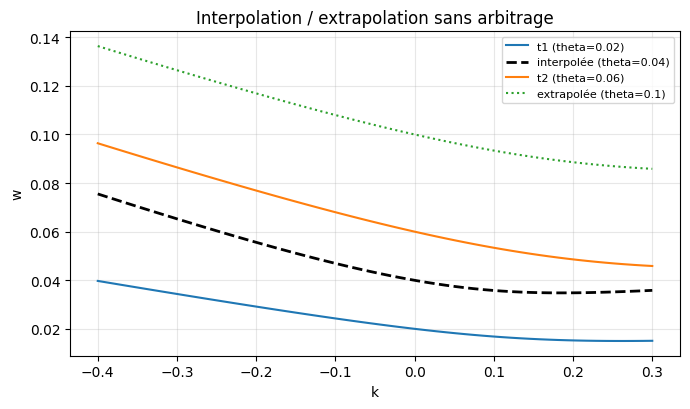

In [9]:
def bs_call_fwd(k, w):
    """Prix de call (forward, non actualisé) en log-moneyness, F=1, à partir de w=sigma^2 t."""
    sq = np.sqrt(w)
    dp = -k / sq + sq / 2; dm = -k / sq - sq / 2
    return norm.cdf(dp) - np.exp(k) * norm.cdf(dm)   # F=1, K=e^k

def iv_total_var_from_call(k, c, lo=1e-6, hi=25.0):
    """Inverse : retrouve w tel que bs_call_fwd(k,w)=c."""
    f = lambda w: bs_call_fwd(k, w) - c
    if f(lo) * f(hi) > 0: return np.nan
    return brentq(f, lo, hi, xtol=1e-12)

def interpolate_slice(k, w1, w2, theta1, theta2, theta_t):
    """Interpolation sans arbitrage (Lemma 5.1) : renvoie w(k,t)."""
    alpha = (np.sqrt(theta2) - np.sqrt(theta_t)) / (np.sqrt(theta2) - np.sqrt(theta1))
    c1 = bs_call_fwd(k, w1); c2 = bs_call_fwd(k, w2)
    ct = alpha * c1 + (1 - alpha) * c2
    return np.array([iv_total_var_from_call(kk, cc) for kk, cc in zip(np.atleast_1d(k), np.atleast_1d(ct))])

# deux tranches SSVI sans arbitrage
th1, th2 = 0.02, 0.06
kk = np.linspace(-0.4, 0.3, 60)
w1 = ssvi_w(kk, th1, **TRUE); w2 = ssvi_w(kk, th2, **TRUE)
theta_t = 0.04
w_interp = interpolate_slice(kk, w1, w2, th1, th2, theta_t)

# non-arbitrage de la tranche interpolée (butterfly via g numérique)
def g_numeric(k, w):
    wp = np.gradient(w, k); wpp = np.gradient(wp, k)
    return durrleman_g(k, w, wp, wpp)
g_int = g_numeric(kk, w_interp)
print(f"tranche interpolée : min g = {np.nanmin(g_int[2:-2]):.4f}  "
      f"({'OK sans arbitrage' if np.nanmin(g_int[2:-2])>=-1e-3 else 'arbitrage'})")

# extrapolation au-delà de la dernière tranche
theta_far = 0.10
w_extra = ssvi_w(kk, th2, **TRUE) + (theta_far - th2)
print(f"extrapolation : w croissant partout ? {(bool(np.all(w_extra >= ssvi_w(kk, th2, **TRUE))))}")

plt.figure(figsize=(7, 4.2))
plt.plot(kk, w1, label=f"t1 (theta={th1})")
plt.plot(kk, w_interp, "k--", lw=2, label=f"interpolée (theta={theta_t})")
plt.plot(kk, w2, label=f"t2 (theta={th2})")
plt.plot(kk, w_extra, ":", label=f"extrapolée (theta={theta_far})")
plt.title("Interpolation / extrapolation sans arbitrage"); plt.xlabel("k"); plt.ylabel("w"); plt.legend(fontsize=8)
plt.tight_layout(); plt.show()


## 7. Récapitulatif — couverture complète du papier

| Technique | Section | Statut |
|---|---|---|
| Raw SVI + dérivées | 3.1 | ✅ |
| SVI naturelle + conversions | 3.2, L3.1 | ✅ (aller-retour validé) |
| SVI-JW + conversions | 3.3, L3.2 | ✅ (Vogt validé, terme corrigé) |
| Butterfly $g(k)\ge0$ + pente d'aile $<2$ | 2.2 | ✅ |
| Crossedness calendaire | 5.1, D5.1 | ✅ |
| Recette de calibration (sqrt-SVI + crossedness) | 5.2 | ✅ |
| Élimination du butterfly (SVI-JW) | 5.1 | ✅ (Exemple 5.1 reproduit) |
| SSVI power-law / Heston-like / modifiée | 4 | ✅ |
| Théorèmes 4.1 (calendar) & 4.2 (butterfly) | 4 | ✅ |
| Interpolation (L5.1) + extrapolation (T4.3) | 5.3 | ✅ |

**Comment articuler NB02 et NB02b dans le mémoire.** NB02 = calibration robuste *par tranche* (Zeliade) pour produire les chiffres du benchmark. NB02b = la **boîte à outils complète** du papier : conversions, garanties d'absence d'arbitrage (butterfly + calendar), interpolation/extrapolation. Pour la soutenance, tu montres que tu maîtrises *tout* l'appareil paramétrique — c'est ce socle qui rend crédible la partie deep learning qui suit.

> Les fonctions ici (conversions, `eliminate_butterfly_jw`, variantes SSVI, `interpolate_slice`) deviendront ton module `svi_toolkit` lors de la refactorisation.
